# Data Visualisation and Communication - CA1

## Employment in AI, Data Science and Software Development

Student: Caio Jacob  
Student Number: 2023168  
Module: Data Visualisation and Communication

GitHub Repository: https://github.com/CCT-Dublin/CA1_Data_Visualisation_and_Communication.git

Video Presentation: [YOUR GOOGLE DRIVE LINK]

## 1. Introduction

This project analyzes a U.S. employment statistics dataset from May 2023. The dataset includes information on various job roles across the United States, detailing employment numbers, mean annual wages, and geographic distribution.
The main focus of this analysis is centered on three tech areas:

* **Artificial Intelligence**
* **Data Science**
* **Software Development**

The objective of this study is to explore and compare employment levels, salary distributions, and market trends within these fields. Through data visualizations, the goal is to understand how these roles differ in earnings and job availability, and to highlight patterns in the U.S. tech job market as of May 2023.

In [11]:
# Import pandas for data loading and DataFrame manipulation
import pandas as pd
# Import NumPy for numerical operations
import numpy as np
# Import Matplotlib for creating visualisations
import matplotlib.pyplot as plt
# Import Seaborn for statistical visualisations
import seaborn as sns

In [13]:
# Define the location of the May 2023 employment dataset
excel_file = r"C:\Users\caioJ\Desktop\IT Course\Semester 7\Data Visualisation and Communication\CA1\all_data_M_2023.xlsx"
# Load the employment data from the relevant worksheet
df = pd.read_excel(
    excel_file,
    sheet_name="All May 2023 data"
)
# Check the number of rows and columns in the dataset
df.shape

(413327, 32)

In [20]:
# Display the column names to understand the structure of the dataset
df.columns

Index(['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE',
       'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP',
       'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT',
       'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN',
       'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75',
       'A_PCT90', 'ANNUAL', 'HOURLY'],
      dtype='object')

In [22]:
# Display the data types of each column in the dataset
df.dtypes

AREA             int64
AREA_TITLE      object
AREA_TYPE        int64
PRIM_STATE      object
NAICS           object
NAICS_TITLE     object
I_GROUP         object
OWN_CODE         int64
OCC_CODE        object
OCC_TITLE       object
O_GROUP         object
TOT_EMP         object
EMP_PRSE        object
JOBS_1000       object
LOC_QUOTIENT    object
PCT_TOTAL       object
PCT_RPT         object
H_MEAN          object
A_MEAN          object
MEAN_PRSE       object
H_PCT10         object
H_PCT25         object
H_MEDIAN        object
H_PCT75         object
H_PCT90         object
A_PCT10         object
A_PCT25         object
A_MEDIAN        object
A_PCT75         object
A_PCT90         object
ANNUAL          object
HOURLY          object
dtype: object

In [24]:
# Display the first five rows of the dataset to inspect the data
df.head()

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,23.11,37.01,58.4,29050,35660,48060,76980,121470,NaN,NaN
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,56.19,81.29,111.36,54550,78330,116880,169090,231620,NaN,NaN
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,49.74,79.57,#,46400,66170,103460,165500,#,NaN,NaN
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN


In [26]:
# Count the missing values in each column of the dataset
df.isnull().sum()

AREA                 0
AREA_TITLE           0
AREA_TYPE            0
PRIM_STATE           0
NAICS                0
NAICS_TITLE          0
I_GROUP              0
OWN_CODE             0
OCC_CODE             0
OCC_TITLE            0
O_GROUP              0
TOT_EMP              0
EMP_PRSE             0
JOBS_1000       177501
LOC_QUOTIENT    177501
PCT_TOTAL       242857
PCT_RPT         242857
H_MEAN               0
A_MEAN               0
MEAN_PRSE            0
H_PCT10              0
H_PCT25              0
H_MEDIAN             0
H_PCT75              0
H_PCT90              0
A_PCT10              0
A_PCT25              0
A_MEDIAN             0
A_PCT75              0
A_PCT90              0
ANNUAL          396830
HOURLY          412572
dtype: int64

In [28]:
# Display selected employment and wage columns to inspect their values
df[['TOT_EMP', 'H_MEAN', 'A_MEAN', 'A_MEDIAN', 'ANNUAL', 'HOURLY']].head()

,TOT_EMP,H_MEAN,A_MEAN,A_MEDIAN,ANNUAL,HOURLY
0,151853870,31.48,65470,48060,NaN,NaN
1,10495770,66.23,137750,116880,NaN,NaN
2,3751510,65.43,136100,103460,NaN,NaN
3,211230,124.47,258900,206680,NaN,NaN
4,211230,124.47,258900,206680,NaN,NaN


In [30]:
# Display the unique occupation titles in the dataset
df['OCC_TITLE'].unique()

array(['All Occupations', 'Management Occupations', 'Top Executives', ...,
       'Tank Car, Truck, and Ship Loaders',
       'Miscellaneous Material Moving Workers',
       'Material Moving Workers, All Other'], dtype=object)

In [32]:
# Select occupation titles containing the term "Data Scientist"
df[df['OCC_TITLE'].str.contains('Data Scientist', na=False)]['OCC_TITLE'].unique()

array(['Data Scientists'], dtype=object)

In [34]:
# Select occupation titles containing the term "Software Developer"
df[df['OCC_TITLE'].str.contains('Software Developer', na=False)]['OCC_TITLE'].unique()

array(['Software Developers'], dtype=object)

In [36]:
# Select occupation titles containing the term "Artificial Intelligence"
df[df['OCC_TITLE'].str.contains('Artificial Intelligence', na=False)]['OCC_TITLE'].unique()

array([], dtype=object)

In [38]:
# Select occupation titles containing the term "Intelligence"
df[df['OCC_TITLE'].str.contains('Intelligence', na=False)]['OCC_TITLE'].unique()

array([], dtype=object)

In [40]:
# Select occupation titles containing the term "Computer"
df[df['OCC_TITLE'].str.contains('Computer', na=False)]['OCC_TITLE'].unique()

array(['Computer and Information Systems Managers',
       'Computer and Mathematical Occupations', 'Computer Occupations',
       'Computer and Information Analysts', 'Computer Systems Analysts',
       'Computer and Information Research Scientists',
       'Computer Support Specialists',
       'Computer Network Support Specialists',
       'Computer User Support Specialists', 'Computer Network Architects',
       'Network and Computer Systems Administrators',
       'Computer Programmers', 'Miscellaneous Computer Occupations',
       'Computer Occupations, All Other', 'Computer Hardware Engineers',
       'Electronics Engineers, Except Computer',
       'Math and Computer Science Teachers, Postsecondary',
       'Computer Science Teachers, Postsecondary',
       'Office Machine Operators, Except Computer',
       'Computer, Automated Teller, and Office Machine Repairers',
       'Computer Numerically Controlled Tool Operators and Programmers',
       'Computer Numerically Controlled

In [42]:
# Select the occupation related to computer and information research
df[df['OCC_TITLE'] == 'Computer and Information Research Scientists']

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
137,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,15-1220,Computer and Information Research Scientists,...,69.75,89.02,112.07,81450,109990,145080,185160,233110,NaN,NaN
138,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,15-1221,Computer and Information Research Scientists,...,69.75,89.02,112.07,81450,109990,145080,185160,233110,NaN,NaN
1535,99,U.S.,1,US,000001,"Cross-industry, Private Ownership only","cross-industry, ownership",5,15-1220,Computer and Information Research Scientists,...,82.78,100.89,#,99620,135940,172190,209850,#,NaN,NaN
1536,99,U.S.,1,US,000001,"Cross-industry, Private Ownership only","cross-industry, ownership",5,15-1221,Computer and Information Research Scientists,...,82.78,100.89,#,99620,135940,172190,209850,#,NaN,NaN
3729,99,U.S.,1,US,22,Utilities,sector,5,15-1220,Computer and Information Research Scientists,...,63.67,64.04,79.37,103250,107350,132430,133200,165100,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234995,77200,"Providence-Warwick, RI-MA",4,RI,000000,Cross-industry,cross-industry,1235,15-1221,Computer and Information Research Scientists,...,60.84,69.24,78.94,80000,94470,126550,144020,164200,NaN,NaN
234996,78100,"Springfield, MA-CT",4,MA,000000,Cross-industry,cross-industry,1235,15-1221,Computer and Information Research Scientists,...,63.67,64.49,79.37,84100,99280,132430,134150,165100,NaN,NaN
371276,2800004,Southwest Mississippi nonmetropolitan area,6,MS,000000,Cross-industry,cross-industry,1235,15-1221,Computer and Information Research Scientists,...,53.81,70.06,72.74,73200,88980,111920,145720,151300,NaN,NaN
371277,3300006,West Central-Southwest New Hampshire nonmetrop...,6,NH,000000,Cross-industry,cross-industry,1235,15-1221,Computer and Information Research Scientists,...,50.74,66.07,86.22,62790,86320,105540,137420,179350,NaN,NaN


In [44]:
# Select the U.S. cross-industry records for Computer and Information Research Scientists
df[
    (df['AREA_TITLE'] == 'U.S.') &
    (df['NAICS_TITLE'] == 'Cross-industry') &
    (df['OCC_TITLE'] == 'Computer and Information Research Scientists')
][['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEAN', 'A_MEDIAN']]

,OCC_CODE,OCC_TITLE,TOT_EMP,A_MEAN,A_MEDIAN
137,15-1220,Computer and Information Research Scientists,35210,157160,145080
138,15-1221,Computer and Information Research Scientists,35210,157160,145080


In [46]:
# Select the U.S. cross-industry records for Data Scientists
df[
    (df['AREA_TITLE'] == 'U.S.') &
    (df['NAICS_TITLE'] == 'Cross-industry') &
    (df['OCC_TITLE'] == 'Data Scientists')
][['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEAN', 'A_MEDIAN']]

,OCC_CODE,OCC_TITLE,TOT_EMP,A_MEAN,A_MEDIAN
164,15-2050,Data Scientists,192710,119040,108020
165,15-2051,Data Scientists,192710,119040,108020


In [48]:
# Select the U.S. cross-industry records for Software Developers
df[
    (df['AREA_TITLE'] == 'U.S.') &
    (df['NAICS_TITLE'] == 'Cross-industry') &
    (df['OCC_TITLE'] == 'Software Developers')
][['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEAN', 'A_MEDIAN']]

,OCC_CODE,OCC_TITLE,TOT_EMP,A_MEAN,A_MEDIAN
149,15-1252,Software Developers,1656880,138110,132270


In [50]:
# Create a smaller DataFrame with the selected occupations and employment measures
ai_employment = df[
    (df['AREA_TITLE'] == 'U.S.') &
    (df['NAICS_TITLE'] == 'Cross-industry') &
    (df['OCC_TITLE'].isin([
        'Computer and Information Research Scientists',
        'Data Scientists',
        'Software Developers'
    ]))
][['OCC_TITLE', 'TOT_EMP', 'A_MEAN', 'A_MEDIAN']]

ai_employment

,OCC_TITLE,TOT_EMP,A_MEAN,A_MEDIAN
137,Computer and Information Research Scientists,35210,157160,145080
138,Computer and Information Research Scientists,35210,157160,145080
149,Software Developers,1656880,138110,132270
164,Data Scientists,192710,119040,108020
165,Data Scientists,192710,119040,108020


In [52]:
# Select one occupation code for each of the three areas being analysed
ai_employment = df[
    (df['AREA_TITLE'] == 'U.S.') &
    (df['NAICS_TITLE'] == 'Cross-industry') &
    (df['OCC_CODE'].isin(['15-1220', '15-2050', '15-1252']))
][['OCC_TITLE', 'TOT_EMP', 'A_MEAN', 'A_MEDIAN']]

ai_employment

,OCC_TITLE,TOT_EMP,A_MEAN,A_MEDIAN
137,Computer and Information Research Scientists,35210,157160,145080
149,Software Developers,1656880,138110,132270
164,Data Scientists,192710,119040,108020


## 2. Employment Comparison

### Objective
The objective of this section is to compare the total number of employed workers (`TOT_EMP`) across three key technology roles in the United States: Software Developers, Data Scientists, and Computer & Information Research Scientists (which represents AI research roles).

### Why This Visualisation?
A vertical bar chart was chosen for this comparison because we are comparing discrete categories (job titles) using a single quantitative measure (total employment). Bar charts make volume differences immediately visible, allowing for an intuitive comparison of scale between the different fields.

### What We Learned
Looking at the U.S. employment data from May 2023:
* **Software Developers** make up the vast majority of the tech workforce with **1,656,880 jobs**.
* **Data Scientists** account for **192,710 jobs**, which is a solid market size but roughly 8 times smaller than Software Development.
* **AI & Computer Research Scientists** account for **35,210 jobs**, showing that specialized AI research remains a smaller, highly niche area.

Overall, the data shows that Software Development had a much larger employment level than Data Science and Computer and Information Research Scientists in the United States in May 2023. This suggests that software development represented a substantially larger area of employment, while Data Science and specialised computer research represented smaller employment groups.

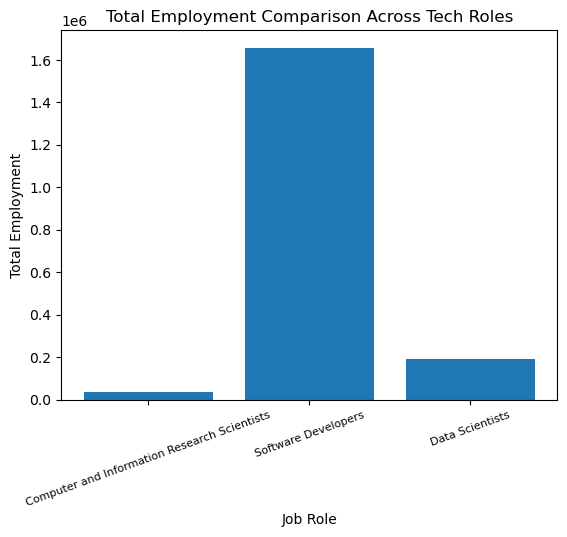

In [78]:
# Create a bar chart comparing total employment across the three roles
plt.bar(ai_employment['OCC_TITLE'], ai_employment['TOT_EMP'])

# Add a title and labels to the chart
plt.title('Total Employment Comparison Across Tech Roles')
plt.xlabel('Job Role')
plt.ylabel('Total Employment')

# Rotate and resize the job role labels for better readability
plt.xticks(rotation=20, fontsize=8)

# Display the chart
plt.show()

## 3. Employment Share by Technology Role

### Objective
The objective of this section is to investigate the proportion of total employment represented by each of the three selected technology roles (Software Developers, Data Scientists, and Computer & Information Research Scientists). We want to understand the relative share of employment of each position within this combined tech group.

### Why This Visualisation?
A pie chart was chosen for this section because it is ideal for displaying part-to-whole relationships. It shows how a total (100%) is divided among different categories, making it easy to compare the percentage contribution of each job role at a glance.

### What We Learned
The pie chart shows that Software Developers represented the largest share of employment among the three selected technology roles, accounting for 87.9% of the combined employment. Data Scientists represented 10.2%, while Computer & Information Research Scientists accounted for 1.9%.

This shows that Software Development had a substantially larger employment share than Data Science and specialised computer research in the United States in May 2023. The visualisation also highlights the relatively small proportion of employment represented by specialised computer and information research roles.

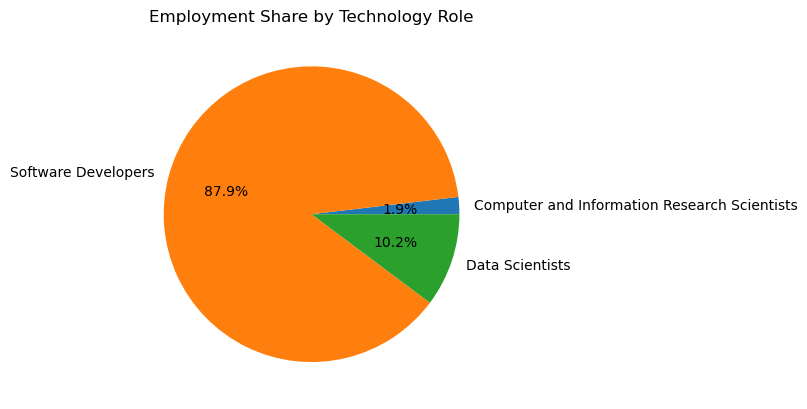

In [89]:
# Create a pie chart showing the employment share across the three roles
plt.pie(ai_employment['TOT_EMP'], labels=ai_employment['OCC_TITLE'], autopct='%1.1f%%')

# Add a title to the chart
plt.title('Employment Share by Technology Role')

# Display the chart
plt.show()